In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### For Normal Data

In [40]:
df = pd.read_csv(r"C:\Users\asifb\OneDrive\Desktop\Python language\Jupyter Notebook\Kaggle\placement.csv")
df.sample(5)

,cgpa,placement_exam_marks,placed
624,7.35,80.0,1
116,7.16,21.0,0
61,7.51,86.0,0
103,6.44,18.0,1
932,6.89,71.0,0


In [7]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


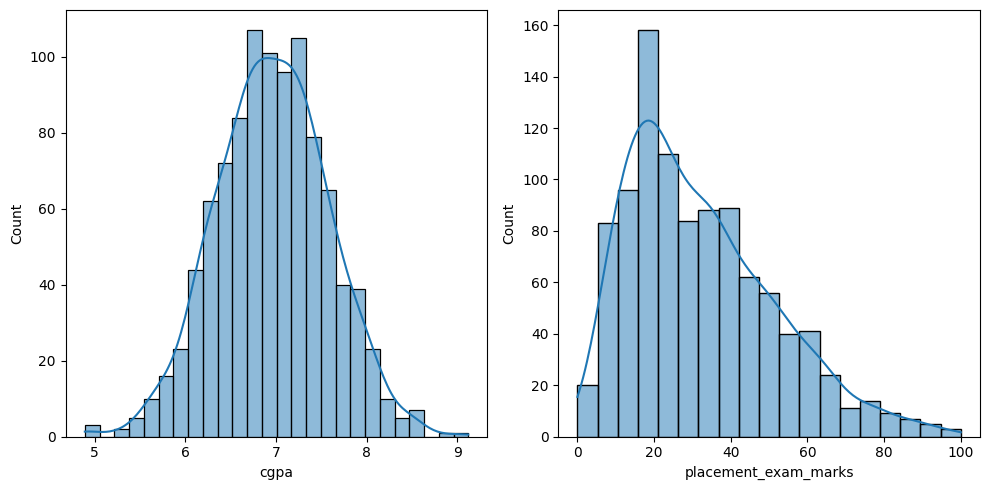

In [16]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(data = df , x= "cgpa" , kde = True)

plt.subplot(1,2,2)
sns.histplot(data = df , x = "placement_exam_marks" , kde = True)

plt.tight_layout()
plt.show()

In [19]:
print(f"Highest Allowed: {df["cgpa"].mean() +  3 *df["cgpa"].std()}")
print(f"Lowest Allowed: {df["cgpa"].mean() -  3 *df["cgpa"].std()}")

Highest Allowed: 8.808933625397168
Lowest Allowed: 5.113546374602832


In [22]:
# outliers 
df[(df["cgpa"] > 8.809) | (df["cgpa"] < 5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [25]:
# Trimming --> Removing outliers 

df_new = df[(df["cgpa"] <8.809 ) & (df["cgpa"] >5.11)]
df_new.count()

cgpa                    995
placement_exam_marks    995
placed                  995
dtype: int64

In [27]:
# Second Approach 
# Calculating Z-Score 

df["Z-Score"] = (df["cgpa"] - df["cgpa"].mean()) / df["cgpa"].std()

df.sample(10)

,cgpa,placement_exam_marks,placed,Z-Score
35,7.48,12.0,0,0.842282
0,7.19,26.0,1,0.371425
327,8.21,56.0,0,2.027544
904,7.36,32.0,0,0.647445
796,6.02,60.0,0,-1.528240
803,7.19,20.0,1,0.371425
176,7.72,30.0,1,1.231957
101,6.48,26.0,1,-0.781363
406,7.14,17.0,1,0.290243
469,5.86,46.0,1,-1.788024


In [29]:
df[(df["Z-Score"] > 3) | (df["Z-Score"] < -3)]

,cgpa,placement_exam_marks,placed,Z-Score
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [31]:
df_2 = df[(df["Z-Score"] < 3) | (df["Z-Score"] > -3)]
df_2.shape

(1000, 4)

## Capping 

In [34]:
df1 = df.copy()

In [36]:
df1.drop(columns = ["Z-Score"], inplace = True)

In [37]:
df1.columns

Index(['cgpa', 'placement_exam_marks', 'placed'], dtype='str')

In [39]:
Upper_limit = df["cgpa"].mean() + 3*df["cgpa"].std()
Lower_limit = df["cgpa"].mean() - 3*df["cgpa"].std()

In [41]:
df["cgpa"] = np.where(df["cgpa"] > Upper_limit , Upper_limit,                                         # where(condition , if gets true , if gets false)
            np.where(df["cgpa"] < Lower_limit , Lower_limit , df["cgpa"]))

In [46]:
df.shape     # Outliers just got replaced by Upper and lower limit no need to remove them 

(1000, 4)

### For Skewed Data We Use IQR Method.

In [3]:
df.sample(3)

,cgpa,placement_exam_marks,placed
389,5.90,16.0,1
102,5.92,22.0,1
515,7.75,44.0,0


<Axes: xlabel='placement_exam_marks', ylabel='Count'>

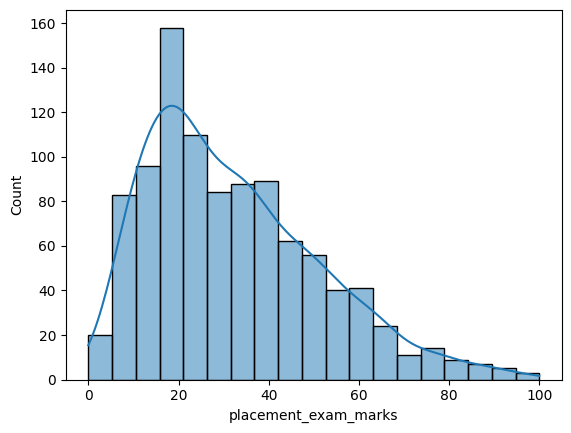

In [4]:
sns.histplot(data = df , x = "placement_exam_marks" , kde = True)

In [8]:
df["placement_exam_marks"].skew(), df["cgpa"].skew()    # more closer to zero = more normal 

(np.float64(0.8356419499466834), np.float64(-0.014529938929314918))

<Axes: ylabel='placement_exam_marks'>

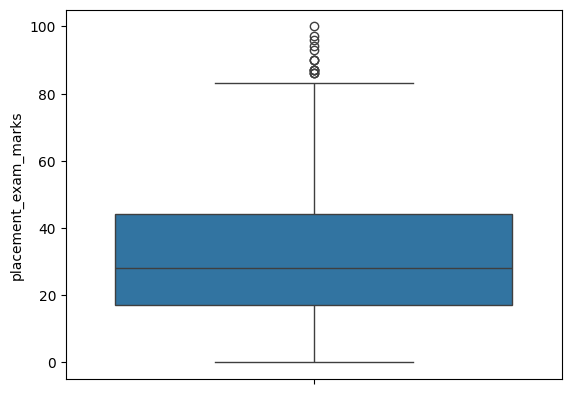

In [9]:
sns.boxplot(df["placement_exam_marks"])

In [10]:
Percentile25 = df["placement_exam_marks"].quantile(0.25)
Percentile75 = df["placement_exam_marks"].quantile(0.75)

In [12]:
IQR = Percentile75 - Percentile25
print(IQR)

27.0


In [18]:
Upper_limit = Percentile75 + 1.5*(IQR)
Lower_limit = Percentile25 - 1.5*(IQR)
print(Upper_limit, Lower_limit)

84.5 -23.5


In [25]:
# list of outliers
df[(df["placement_exam_marks"] > Upper_limit) | (df["placement_exam_marks"] < Lower_limit)].head()

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0


## Trimming 

In [28]:
df_new = df[df["placement_exam_marks"] < Upper_limit]
df_new.shape

(985, 3)

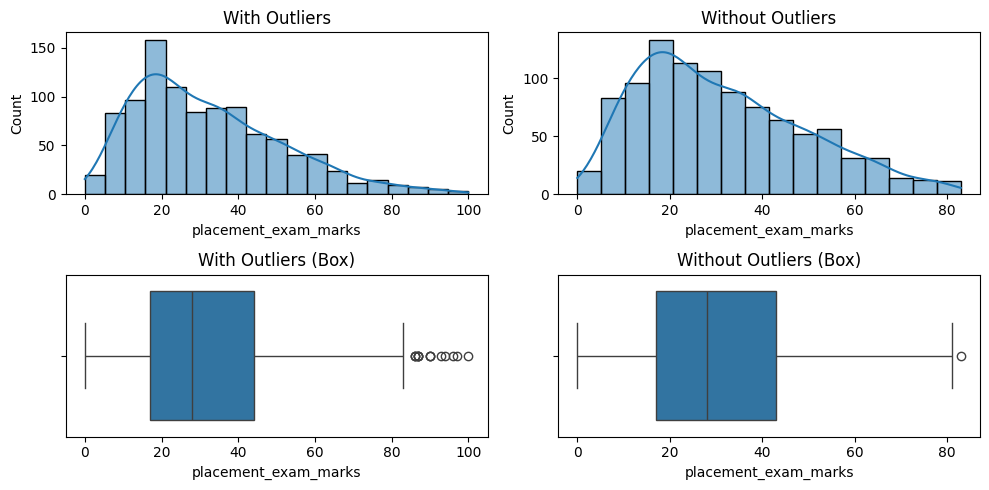

In [37]:
plt.figure(figsize = (10,5))
plt.subplot(2,2,1)
sns.histplot(data = df  , x = "placement_exam_marks", kde = True)
plt.title("With Outliers")

plt.subplot(2,2,2)
sns.histplot(data = df_new , x = "placement_exam_marks", kde = True)
plt.title("Without Outliers")

plt.subplot(2, 2, 3)
sns.boxplot(data=df, x="placement_exam_marks")
plt.title("With Outliers (Box)")

plt.subplot(2, 2, 4)
sns.boxplot(data=df_new, x="placement_exam_marks")
plt.title("Without Outliers (Box)")

plt.tight_layout()
plt.show()

In [31]:
df_new["placement_exam_marks"].skew()

np.float64(0.6549925627115251)

## Capping 

In [41]:
df_new1 =df.copy()

df_new1["placement_exam_marks"] = np.where(df["placement_exam_marks"] > Upper_limit , Upper_limit ,
                  np.where(df["placement_exam_marks"] < Lower_limit , Lower_limit , df["placement_exam_marks"]))

In [44]:
df_new1.shape

(1000, 3)

<Axes: xlabel='placement_exam_marks'>

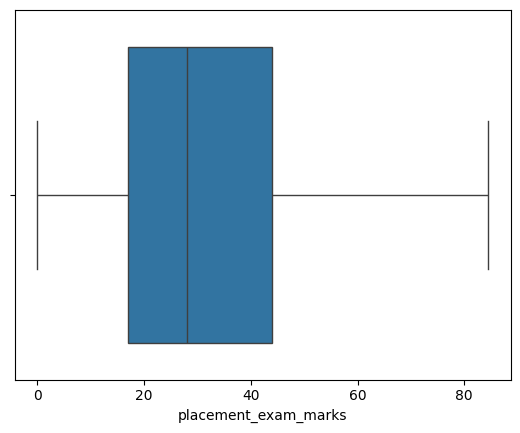

In [46]:
sns.boxplot(data = df_new1 , x = "placement_exam_marks")